# Redispatch sanity check — grid-operator lens
Source: `data/raw/shn_operations_last_2y/*.parquet` (Schleswig-Holstein Netz DSO, north Germany — wind-heavy region).
Window: **2024-01-01 → 2026-04-01** (capped to external-data coverage).

Each raw row is one **asset** (transformer/feeder) inside a redispatch operation. Multiple assets share an `operationId` and a constrained transformer (`locationBottleneck`, e.g. `…-T122`).
One **op** = unique `(start, end, location)` tuple — that's the correct unit for the time series.

Reason codes (grid-analyst reading):
- `Netzengpass I/U` — congestion on the internal grid (primary driver).
- `TenneT2` — upstream TSO-triggered curtailment.
- `Sonstiges` / `Sonstige` — 'other'.
- `Funktionsnachweis` — functional test (not a real congestion event; candidate to drop).
- `Spitzenkappung` — peak-capping (EEG §11.2).
- `Abschaltung Erzeugung` — generation shutdown.

`liabilityOfCompensation`: **EEG** = renewable feed-in curtailment (DSO pays producer); **EnWG** = conventional redispatch.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent

OPS_DIR      = ROOT / 'data' / 'raw' / 'shn_operations_last_2y'
EXTERNAL_PQ  = ROOT / 'data' / 'external' / 'smard_weather_2024_to_mar2026.parquet'

START_CUTOFF = pd.Timestamp('2024-01-01')
END_CUTOFF   = pd.Timestamp('2026-04-01')   # match external-data upper bound
WEEK_MIN     = 7 * 24 * 60

print(f'ops dir  : {OPS_DIR}  (exists: {OPS_DIR.exists()})')
print(f'external : {EXTERNAL_PQ}  (exists: {EXTERNAL_PQ.exists()})')
print(f'window   : {START_CUTOFF.date()}  →  {END_CUTOFF.date()}')

ops dir  : c:\Users\ashis\OneDrive\Desktop\Restart\Projects\Redispatch\data\raw\shn_operations_last_2y  (exists: True)
external : c:\Users\ashis\OneDrive\Desktop\Restart\Projects\Redispatch\data\external\smard_weather_2024_to_mar2026.parquet  (exists: True)
window   : 2024-01-01  →  2026-04-01


## 1. Load raw

In [9]:
files = sorted(OPS_DIR.glob('chunk_*.parquet'))
raw = pd.concat([pd.read_parquet(f) for f in files], ignore_index=True)
raw['start'] = pd.to_datetime(raw['start'])
raw['end']   = pd.to_datetime(raw['end'])
print(f'raw asset-level rows: {len(raw):,}')
print(f'raw date range     : {raw["start"].min()}  →  {raw["start"].max()}')

raw asset-level rows: 983,500
raw date range     : 2023-04-29 15:36:15  →  2026-04-22 16:19:34


## 2. Cleaning pipeline
Applied as a single auditable sequence. Each step reports rows in / rows out.

In [10]:
def step(name, before, after):
    print(f'  {name:<42}  {before:>8,}  →  {after:>8,}   (-{before-after:,})')

df = raw.copy()
n0 = len(df)
print(f'start: {n0:,} asset-level rows\n')

# (a) window
b = len(df); df = df[(df['start'] >= START_CUTOFF) & (df['start'] < END_CUTOFF)].reset_index(drop=True)
step('window 2024-01-01 → 2026-04-01', b, len(df))

# (b) drop dead columns
df = df.drop(columns=['srId', 'Reason'])   # srId 100% NaN, Reason duplicates reason
print('  drop srId (all NaN) and Reason (dup)')

# (c) drop 'UW' placeholder
b = len(df); df = df[df['location'] != 'UW'].reset_index(drop=True)
step("drop location=='UW' placeholder", b, len(df))

# (d) collapse asset-level → op-level
b = len(df); df_ops = df.drop_duplicates(subset=['start', 'end', 'location']).reset_index(drop=True)
step('dedup to unique ops (start,end,location)', b, len(df_ops))

# (e) duration_calc, drop sentinel / negative / >1 week
df_ops['duration_min'] = (df_ops['end'] - df_ops['start']).dt.total_seconds() / 60
b = len(df_ops); df_ops = df_ops[(df_ops['duration_min'] > 0) & (df_ops['duration_min'] <= WEEK_MIN)].reset_index(drop=True)
step('drop bad duration (<=0 or >1 week)', b, len(df_ops))

# (f) normalize town; explode multi-town rows
df_ops['town_raw'] = df_ops['location'].str.replace(r'^UW\s+', '', regex=True).str.strip()
df_ops['town_list'] = df_ops['town_raw'].str.split(',').apply(
    lambda xs: [t.replace('UW ', '').strip() for t in xs]
)
df_town = df_ops.explode('town_list').rename(columns={'town_list': 'town'}).reset_index(drop=True)
print(f'\nop-level rows           : {len(df_ops):,}')
print(f'after exploding multi-town: {len(df_town):,}  (fan-out factor {len(df_town)/len(df_ops):.3f})')
print(f'unique towns              : {df_town["town"].nunique()}')

start: 983,500 asset-level rows

  window 2024-01-01 → 2026-04-01               983,500  →   750,151   (-233,349)
  drop srId (all NaN) and Reason (dup)
  drop location=='UW' placeholder              750,151  →   716,842   (-33,309)
  dedup to unique ops (start,end,location)     716,842  →   253,346   (-463,496)
  drop bad duration (<=0 or >1 week)           253,346  →   252,710   (-636)

op-level rows           : 252,710
after exploding multi-town: 270,307  (fan-out factor 1.070)
unique towns              : 190


## 3. Where is the grid hurting? — towns & transformers

In [11]:
# ops per town + total constrained minutes per town (intensity)
town_stats = (df_town.groupby('town')
              .agg(ops=('start', 'size'),
                   total_min=('duration_min', 'sum'),
                   median_min=('duration_min', 'median'))
              .sort_values('total_min', ascending=False))
town_stats['total_hours'] = town_stats['total_min'] / 60
print('Top 15 towns by total constrained hours:')
town_stats.head(15)

Top 15 towns by total constrained hours:


,ops,total_min,median_min,total_hours
town,,,,
Niebüll,18762,3.971790e+06,68.233333,66196.496111
Marne West,16806,2.920931e+06,52.091667,48682.179444
Linden,5085,2.532277e+06,119.266667,42204.621944
Itzehoe Mitte,9600,2.305190e+06,101.341667,38419.825000
Brachenfeld,9564,2.289689e+06,101.200000,38161.475833
Reinsbüttel,7774,2.274050e+06,134.141667,37900.827500
Wöhrden,9028,1.440004e+06,58.900000,24000.061667
Lütjenbrode,6983,1.342208e+06,73.633333,22370.133056
Lensahn,5425,1.338389e+06,55.200000,22306.489167


In [12]:
# Top constrained transformers (locationBottleneck identifies the transformer, e.g. '...-T122')
bn = (df_ops.groupby('locationBottleneck')
      .agg(ops=('start', 'size'),
           total_hours=('duration_min', lambda s: s.sum()/60),
           example_location=('location', 'first'))
      .sort_values('total_hours', ascending=False))
print(f'unique bottleneck transformers: {len(bn):,}')
print('\nTop 15 by constrained hours:')
bn.head(15)

unique bottleneck transformers: 2,594

Top 15 by constrained hours:


,ops,total_hours,example_location
locationBottleneck,,,
,91997,210797.793611,UW Hademarschen
SK000841#SHAZ-A.HOBS,8550,43640.567222,UW Lütjenbrode
STUW46200-T411,4867,42028.812500,UW Reinsbüttel
SK000696#A.ROGE-ROGE,10426,32199.077778,UW Rogerfelde
1000374893-T411,3020,17433.626111,UW Reinsbüttel
STUW46100-T412,1703,16831.846389,UW Marne West
SK002380#ITZM-HOLO,6221,14673.498056,"UW Brachenfeld,UW Itzehoe Mitte"
STUW47810-T414,1748,12921.918611,UW Löwenstedt
STUW47810-T412,1577,11378.606944,UW Handewitt


## 4. Duration, concurrency & dispatch-desk load

duration (min) — clean ops:
count    252710.0
mean        215.7
std         465.4
min           0.0
50%          75.9
90%         481.1
99%        1917.3
max       10065.2
Name: duration_min, dtype: float64


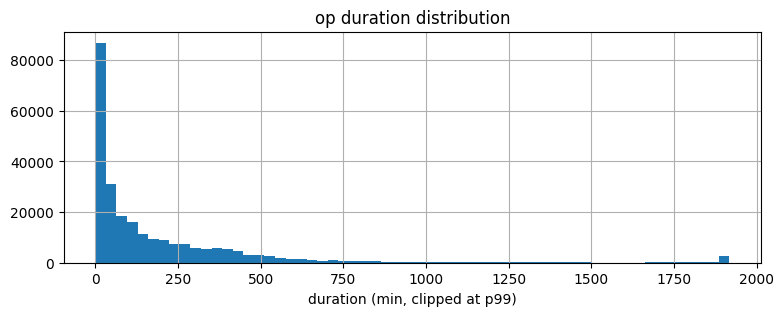

In [13]:
print('duration (min) — clean ops:')
print(df_ops['duration_min'].describe(percentiles=[.5, .9, .99]).round(1))

fig, ax = plt.subplots(figsize=(9, 3))
df_ops['duration_min'].clip(upper=df_ops['duration_min'].quantile(0.99)).hist(bins=60, ax=ax)
ax.set_xlabel('duration (min, clipped at p99)')
ax.set_title('op duration distribution')
plt.show()

concurrent ops — distribution:
count    505420.0
mean        198.3
std         210.4
min           0.0
50%         128.0
90%         491.0
99%         986.0
max        1282.0
Name: concurrent, dtype: float64


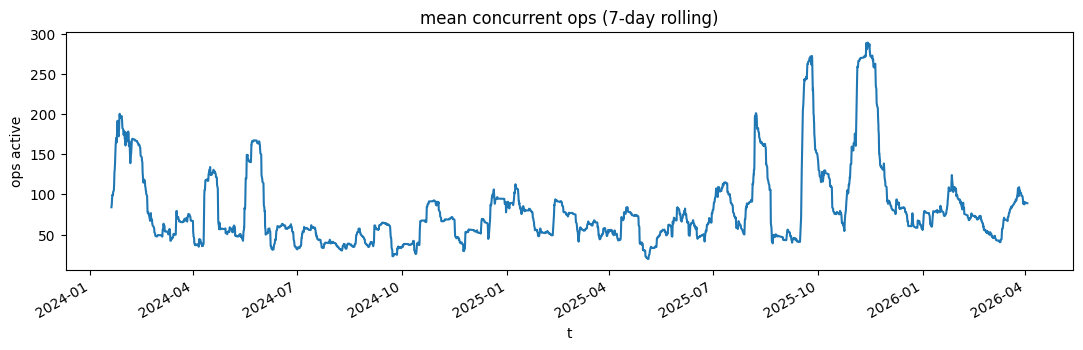

In [14]:
# concurrent ops — sweep-line on start/end events
events = pd.concat([
    df_ops[['start']].rename(columns={'start': 't'}).assign(delta=1),
    df_ops[['end']].rename(columns={'end': 't'}).assign(delta=-1),
]).sort_values('t').reset_index(drop=True)
events['concurrent'] = events['delta'].cumsum()

print('concurrent ops — distribution:')
print(events['concurrent'].describe(percentiles=[.5, .9, .99]).round(1))

# hourly mean concurrency
conc_h = (events.set_index('t')['concurrent']
          .resample('1h').mean().dropna())
fig, ax = plt.subplots(figsize=(13, 3.5))
conc_h.rolling(24*7).mean().plot(ax=ax)
ax.set_title('mean concurrent ops (7-day rolling)')
ax.set_ylabel('ops active')
plt.show()

## 5. Reason × liability — what drives redispatch here?
`Netzengpass*` + `EEG` = renewable (wind) curtailment for internal grid congestion — the SHN signature.

In [15]:
ct = pd.crosstab(df_ops['reason'], df_ops['liabilityOfCompensation'], margins=True, margins_name='total')
ct_sorted = ct.sort_values('total', ascending=False)
print('reason × liability (op count):')
print(ct_sorted)

print('\ncontrol stage × liability (op count):')
print(pd.crosstab(df_ops['controlStage'], df_ops['liabilityOfCompensation']))

reason × liability (op count):
liabilityOfCompensation     EEG   EnWG   total
reason                                        
total                    218929  33781  252710
Netzengpass I            153045    177  153222
Netzengpass               37000    226   37226
Sonstiges                  1158  21747   22905
TenneT2                   19822      0   19822
Sonstige                     92   8776    8868
Funktionsnachweis          3281   1450    4731
Netzengpass Sonstiges      3847     17    3864
Abschaltung Erzeugung        38   1384    1422
Netzengpass U               605      0     605
Spitzenkappung               41      4      45

control stage × liability (op count):
liabilityOfCompensation     EEG   EnWG
controlStage                          
0                        157421  31694
20                            1      0
30                        22860   1245
60                        38647    842


## 6. Temporal patterns — hour × weekday heatmap
Wind-driven curtailments should spike overnight (low load, high wind). Weekend vs weekday shows demand vs wind dominance.

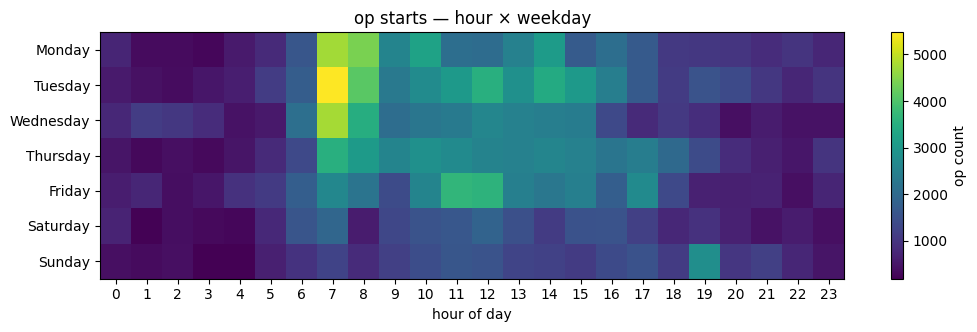

In [16]:
df_ops['hour'] = df_ops['start'].dt.hour
df_ops['dow']  = df_ops['start'].dt.day_name()
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
heat = (df_ops.groupby(['dow', 'hour']).size()
        .unstack('hour').reindex(dow_order).fillna(0))

fig, ax = plt.subplots(figsize=(12, 3.2))
im = ax.imshow(heat.values, aspect='auto', cmap='viridis')
ax.set_xticks(range(24)); ax.set_xticklabels(range(24))
ax.set_yticks(range(7));  ax.set_yticklabels(dow_order)
ax.set_xlabel('hour of day'); ax.set_title('op starts — hour × weekday')
plt.colorbar(im, ax=ax, label='op count')
plt.show()

## 7. Load external cache & sanity-link to redispatch
Hourly SMARD + weather. Quick check: does high wind-onshore generation coincide with more ops?

In [17]:
ext = pd.read_parquet(EXTERNAL_PQ)
ext['timestamp'] = pd.to_datetime(ext['timestamp'], utc=True).dt.tz_localize(None)
print(f'external rows : {len(ext):,}')
print(f'range         : {ext["timestamp"].min()}  →  {ext["timestamp"].max()}')
wanted = ['residual_load', 'wind_onshore', 'wind_offshore', 'solar', 'day_ahead',
          'wx_wind_speed_100m', 'wx_shortwave_radiation', 'wx_temperature_2m', 'wx_cloud_cover']
print('\nNaN in model-ready columns:')
print(ext[wanted].isna().sum())

external rows : 19,705
range         : 2024-01-01 00:00:00  →  2026-04-01 00:00:00

NaN in model-ready columns:
residual_load             0
wind_onshore              0
wind_offshore             0
solar                     0
day_ahead                 0
wx_wind_speed_100m        1
wx_shortwave_radiation    1
wx_temperature_2m         1
wx_cloud_cover            1
dtype: int64


Pearson correlation of hourly op count with:
wind_onshore     0.123
residual_load   -0.026
Name: ops, dtype: float64


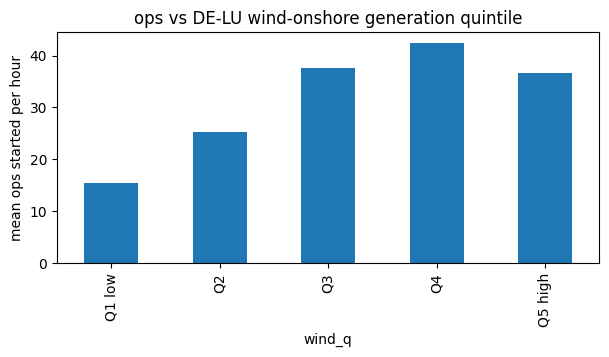

In [18]:
# hourly op count vs wind_onshore
ops_hourly = (df_ops.assign(hr=lambda d: d['start'].dt.floor('h'))
              .groupby('hr').size().rename('ops'))
merged = (ext.set_index('timestamp')[['wind_onshore', 'residual_load']]
          .join(ops_hourly, how='inner'))
merged['ops'] = merged['ops'].fillna(0)

corr = merged.corr().loc['ops']
print('Pearson correlation of hourly op count with:')
print(corr.drop('ops').round(3))

# quintile plot — mean hourly ops by wind quintile
merged['wind_q'] = pd.qcut(merged['wind_onshore'], 5, labels=['Q1 low','Q2','Q3','Q4','Q5 high'])
q = merged.groupby('wind_q', observed=True)['ops'].mean()
fig, ax = plt.subplots(figsize=(7, 3))
q.plot(kind='bar', ax=ax)
ax.set_ylabel('mean ops started per hour')
ax.set_title('ops vs DE-LU wind-onshore generation quintile')
plt.show()

## 8. Summary counters + decision gate

In [19]:
print('=== clean dataset ready ===')
print(f'asset rows (raw, in window)   : {((raw["start"] >= START_CUTOFF) & (raw["start"] < END_CUTOFF)).sum():,}')
print(f'op-level rows                 : {len(df_ops):,}')
print(f'town-exploded rows            : {len(df_town):,}')
print(f'unique locations              : {df_ops["location"].nunique()}')
print(f'unique towns                  : {df_town["town"].nunique()}')
print(f'unique bottleneck transformers: {df_ops["locationBottleneck"].nunique()}')
print(f'ops date range                : {df_ops["start"].min()}  →  {df_ops["start"].max()}')
print('\nNext: src/build_timeseries.py — range-join df_town to 15-min grid × town list → ts_15min.parquet')

=== clean dataset ready ===
asset rows (raw, in window)   : 750,151
op-level rows                 : 252,710
town-exploded rows            : 270,307
unique locations              : 217
unique towns                  : 190
unique bottleneck transformers: 2594
ops date range                : 2024-01-01 00:02:28  →  2026-03-31 20:53:05

Next: src/build_timeseries.py — range-join df_town to 15-min grid × town list → ts_15min.parquet
